# Getting reach average shear stresses 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy.stats import linregress
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score

# import dicharge data and make date the index
discharge = pd.read_csv('la_jara_reconstructed_discharge_rsa.csv', index_col='timestamp', parse_dates=True)

## Average Shear Stress 

In [2]:
# import shear stress data and make date the index
shear_stress_2022 = pd.read_csv('../../shear_stress_2022.csv', index_col='time', parse_dates=True)
shear_stress_2023 = pd.read_csv('../../shear_stress_2023.csv', index_col='time', parse_dates=True)

### Merge shear stress data onto discharge dataframe

In [3]:
# merge shear stress data onto discharge dataframe 
discharge = discharge.merge(shear_stress_2022, left_index=True, right_index=True, how='left')
discharge = discharge.merge(shear_stress_2023, left_index=True, right_index=True, how='left')
discharge

,discharge,0_x,0_y
timestamp,,,
2022-07-14 00:00:00,0.015821,63.980729,NaN
2022-07-14 00:15:00,0.014952,63.197592,NaN
2022-07-14 00:30:00,0.015821,63.500266,NaN
2022-07-14 00:45:00,0.014952,62.623471,NaN
2022-07-14 01:00:00,0.015528,63.247582,NaN
...,...,...,...
2023-09-18 22:45:00,0.005250,NaN,NaN
2023-09-18 23:00:00,0.005250,NaN,NaN
2023-09-18 23:15:00,0.005250,NaN,NaN


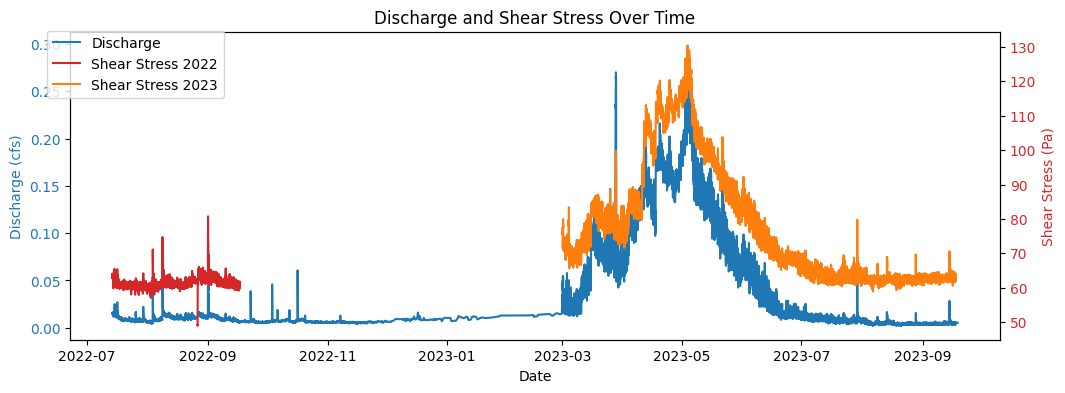

In [4]:
# plot discharge and shear stress over time
fig, ax1 = plt.subplots(figsize=(12, 4))
ax1.set_xlabel('Date')
ax1.set_ylabel('Discharge (cfs)', color='tab:blue') 
ax1.plot(discharge.index, discharge['discharge'], color='tab:blue', label='Discharge')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax2 = ax1.twinx()
ax2.set_ylabel('Shear Stress (Pa)', color='tab:red')
ax2.plot(discharge.index, discharge['0_x'], color='tab:red', label='Shear Stress 2022')
ax2.plot(discharge.index, discharge['0_y'], color='tab:orange', label='Shear Stress 2023')
ax2.tick_params(axis='y', labelcolor='tab:red') 
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))
plt.title('Discharge and Shear Stress Over Time')
plt.show()

Scatter plots

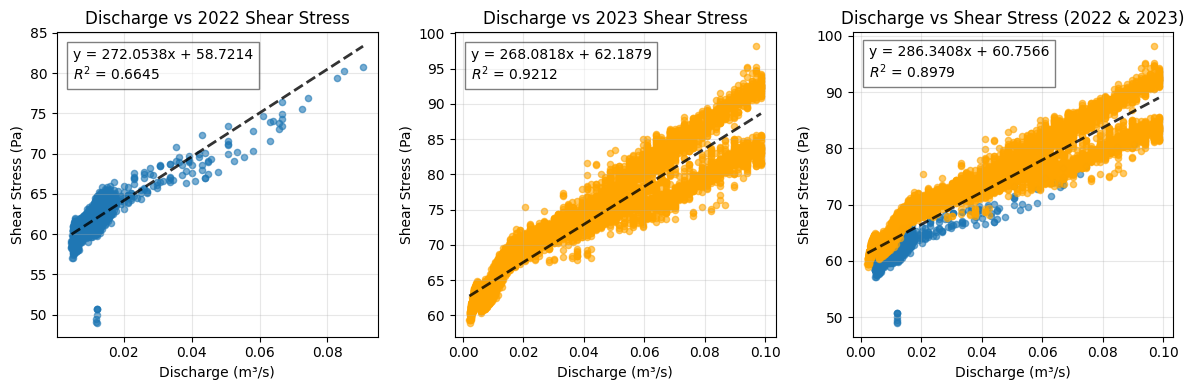

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# clean dataframes without NaN values and filter discharge <= 0.1
df_clean_2022 = discharge[['discharge', '0_x']].dropna()
df_clean_2022 = df_clean_2022[df_clean_2022['discharge'] <= 0.1]
df_clean_2023 = discharge[['discharge', '0_y']].dropna()
df_clean_2023 = df_clean_2023[df_clean_2023['discharge'] <= 0.1]

# discharge vs 2022 shear stress
axes[0].scatter(df_clean_2022['discharge'], df_clean_2022['0_x'], alpha=0.6, s=20)
slope_2022, intercept_2022, r_value_2022, p_value_2022, std_err_2022 = linregress(df_clean_2022['discharge'], df_clean_2022['0_x'])
x_line_2022 = np.array([df_clean_2022['discharge'].min(), df_clean_2022['discharge'].max()])
y_line_2022 = slope_2022 * x_line_2022 + intercept_2022
axes[0].plot(x_line_2022, y_line_2022, color='black', linestyle='--', alpha=0.8, linewidth=2)
axes[0].text(0.05, 0.95, f'y = {slope_2022:.4f}x + {intercept_2022:.4f}\n$R^2$ = {r_value_2022**2:.4f}', 
             transform=axes[0].transAxes, verticalalignment='top', bbox=dict(facecolor='white', alpha=0.5))
axes[0].set_xlabel('Discharge (m³/s)')
axes[0].set_ylabel('Shear Stress (Pa)')
axes[0].set_title('Discharge vs 2022 Shear Stress')
axes[0].grid(True, alpha=0.3)

# discharge vs 2023 shear stress
axes[1].scatter(df_clean_2023['discharge'], df_clean_2023['0_y'], alpha=0.6, s=20, color='orange')
slope_2023, intercept_2023, r_value_2023, p_value_2023, std_err_2023 = linregress(df_clean_2023['discharge'], df_clean_2023['0_y'])
x_line_2023 = np.array([df_clean_2023['discharge'].min(), df_clean_2023['discharge'].max()])
y_line_2023 = slope_2023 * x_line_2023 + intercept_2023
axes[1].plot(x_line_2023, y_line_2023, color='black', linestyle='--', alpha=0.8, linewidth=2)
axes[1].text(0.05, 0.95, f'y = {slope_2023:.4f}x + {intercept_2023:.4f}\n$R^2$ = {r_value_2023**2:.4f}', 
             transform=axes[1].transAxes, verticalalignment='top', bbox=dict(facecolor='white', alpha=0.5))
axes[1].set_xlabel('Discharge (m³/s)')
axes[1].set_ylabel('Shear Stress (Pa)')
axes[1].set_title('Discharge vs 2023 Shear Stress')
axes[1].grid(True, alpha=0.3)

# both years with single fit line
axes[2].scatter(df_clean_2022['discharge'], df_clean_2022['0_x'], alpha=0.6, s=20, label='2022')
axes[2].scatter(df_clean_2023['discharge'], df_clean_2023['0_y'], alpha=0.6, s=20, color='orange', label='2023')
# combine both datasets for single linear fit
combined_data = pd.concat([df_clean_2022[['discharge', '0_x']].rename(columns={'0_x': 'shear_stress'}),
                           df_clean_2023[['discharge', '0_y']].rename(columns={'0_y': 'shear_stress'})])
slope_combined, intercept_combined, r_value_combined, p_value_combined, std_err_combined = linregress(combined_data['discharge'], combined_data['shear_stress'])
x_line_combined = np.array([combined_data['discharge'].min(), combined_data['discharge'].max()])
y_line_combined = slope_combined * x_line_combined + intercept_combined
axes[2].plot(x_line_combined, y_line_combined, color='black', linestyle='--', alpha=0.8, linewidth=2, label=f'Combined fit: $R^2$ = {r_value_combined**2:.4f}')

axes[2].set_xlabel('Discharge (m³/s)')
axes[2].set_ylabel('Shear Stress (Pa)')
axes[2].set_title('Discharge vs Shear Stress (2022 & 2023)')
axes[2].text(0.05, 0.85, f'y = {slope_combined:.4f}x + {intercept_combined:.4f}\n$R^2$ = {r_value_combined**2:.4f}', 
             transform=axes[2].transAxes, bbox=dict(facecolor='white', alpha=0.5))
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

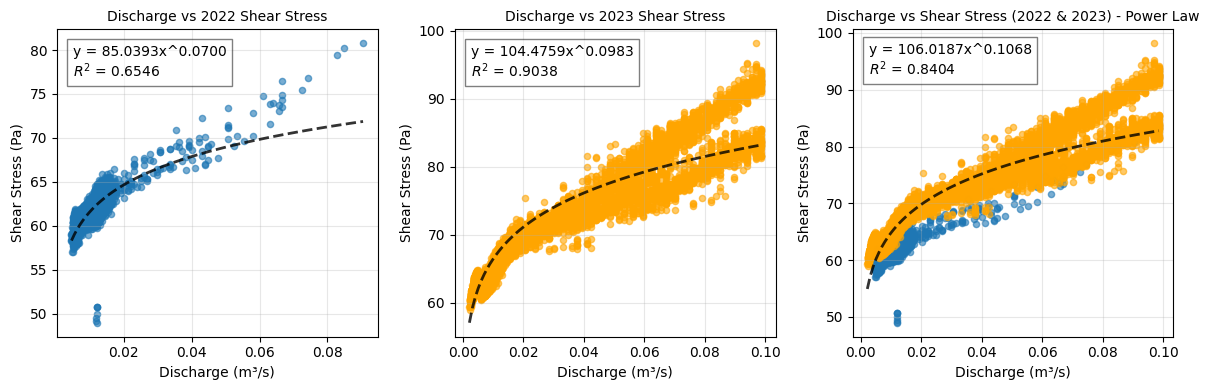

In [6]:
# define power law function
def power_law(x, a, b):
    return a * np.power(x, b)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# discharge vs 2022 shear stress
axes[0].scatter(df_clean_2022['discharge'], df_clean_2022['0_x'], alpha=0.6, s=20)
try:
    popt_2022, pcov_2022 = curve_fit(power_law, df_clean_2022['discharge'], df_clean_2022['0_x'], p0=[1, 2], maxfev=10000)
    x_line_2022_pw = np.linspace(df_clean_2022['discharge'].min(), df_clean_2022['discharge'].max(), 100)
    y_line_2022_pw = power_law(x_line_2022_pw, *popt_2022)
    y_pred_2022_pw = power_law(df_clean_2022['discharge'], *popt_2022)
    r2_2022_pw = r2_score(df_clean_2022['0_x'], y_pred_2022_pw)
    axes[0].plot(x_line_2022_pw, y_line_2022_pw, color='black', alpha=0.8, linewidth=2, linestyle='--')
    axes[0].text(0.05, 0.95, f'y = {popt_2022[0]:.4f}x^{popt_2022[1]:.4f}\n$R^2$ = {r2_2022_pw:.4f}', 
                 transform=axes[0].transAxes, verticalalignment='top', bbox=dict(facecolor='white', alpha=0.5))
except:
    axes[0].text(0.5, 0.5, 'Fit failed', ha='center', va='center', transform=axes[0].transAxes)
axes[0].set_xlabel('Discharge (m³/s)')
axes[0].set_ylabel('Shear Stress (Pa)')
axes[0].set_title('Discharge vs 2022 Shear Stress', fontsize=10)
axes[0].grid(True, alpha=0.3)

# discharge vs 2023 shear stress
axes[1].scatter(df_clean_2023['discharge'], df_clean_2023['0_y'], alpha=0.6, s=20, color='orange')
try:
    popt_2023, pcov_2023 = curve_fit(power_law, df_clean_2023['discharge'], df_clean_2023['0_y'], p0=[1, 2], maxfev=10000)
    x_line_2023_pw = np.linspace(df_clean_2023['discharge'].min(), df_clean_2023['discharge'].max(), 100)
    y_line_2023_pw = power_law(x_line_2023_pw, *popt_2023)
    y_pred_2023_pw = power_law(df_clean_2023['discharge'], *popt_2023)
    r2_2023_pw = r2_score(df_clean_2023['0_y'], y_pred_2023_pw)
    axes[1].plot(x_line_2023_pw, y_line_2023_pw, color='black', alpha=0.8, linewidth=2, linestyle='--')
    axes[1].text(0.05, 0.95, f'y = {popt_2023[0]:.4f}x^{popt_2023[1]:.4f}\n$R^2$ = {r2_2023_pw:.4f}', 
                 transform=axes[1].transAxes, verticalalignment='top', bbox=dict(facecolor='white', alpha=0.5))
except:
    axes[1].text(0.5, 0.5, 'Fit failed', ha='center', va='center', transform=axes[1].transAxes)
axes[1].set_xlabel('Discharge (m³/s)')
axes[1].set_ylabel('Shear Stress (Pa)')
axes[1].set_title('Discharge vs 2023 Shear Stress', fontsize=10)
axes[1].grid(True, alpha=0.3)

# both years with power law fit
axes[2].scatter(df_clean_2022['discharge'], df_clean_2022['0_x'], alpha=0.6, s=20, label='2022')
axes[2].scatter(df_clean_2023['discharge'], df_clean_2023['0_y'], alpha=0.6, s=20, color='orange', label='2023')
try:
    popt_combined, pcov_combined = curve_fit(power_law, combined_data['discharge'], combined_data['shear_stress'], p0=[1, 2], maxfev=10000)
    x_line_combined_pw = np.linspace(combined_data['discharge'].min(), combined_data['discharge'].max(), 100)
    y_line_combined_pw = power_law(x_line_combined_pw, *popt_combined)
    y_pred_combined_pw = power_law(combined_data['discharge'], *popt_combined)
    r2_combined_pw = r2_score(combined_data['shear_stress'], y_pred_combined_pw)
    axes[2].plot(x_line_combined_pw, y_line_combined_pw, color='black', linestyle='--', alpha=0.8, linewidth=2, label=f'Combined fit: $R^2$ = {r2_combined_pw:.4f}')
    axes[2].text(0.05, 0.85, f'y = {popt_combined[0]:.4f}x^{popt_combined[1]:.4f}\n$R^2$ = {r2_combined_pw:.4f}', 
                 transform=axes[2].transAxes, bbox=dict(facecolor='white', alpha=0.5))
except:
    axes[2].text(0.5, 0.5, 'Fit failed', ha='center', va='center', transform=axes[2].transAxes)
axes[2].set_xlabel('Discharge (m³/s)')
axes[2].set_ylabel('Shear Stress (Pa)')
axes[2].set_title('Discharge vs Shear Stress (2022 & 2023) - Power Law', fontsize=10)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Calculate shear stress using equations

In [10]:
# calculate shear stress using year-specific linear fits
# 2022 uses slope_2022/intercept_2022, 2023 uses slope_2023/intercept_2023

discharge['tau_calculated_linear'] = np.nan

q = discharge['discharge']
years = discharge.index.year

# linear fit can be applied to any non-NaN discharge (optionally keep q > 0 if you want)
valid_q = q.notna() & (q > 0)
# apply 2022 fit through end of March 2023 to avoid Jan 01 jump
split_date = pd.Timestamp("2023-04-01")
mask_2022_fit = (discharge.index < split_date) & valid_q
mask_2023_fit = (discharge.index >= split_date) & valid_q

# tau = mQ + b
discharge.loc[mask_2022_fit, "tau_calculated_linear"] = (
    slope_2022 * q.loc[mask_2022_fit] + intercept_2022
)
discharge.loc[mask_2023_fit, "tau_calculated_linear"] = (
    slope_2023 * q.loc[mask_2023_fit] + intercept_2023
)

# optional: prevent negative shear stress values
discharge['tau_calculated_linear'] = discharge['tau_calculated_linear'].clip(lower=0)
# quick check
print(discharge[['discharge', 'tau_calculated_linear']])

                     discharge  tau_calculated_linear
timestamp                                            
2022-07-14 00:00:00   0.015821              63.025517
2022-07-14 00:15:00   0.014952              62.789193
2022-07-14 00:30:00   0.015821              63.025517
2022-07-14 00:45:00   0.014952              62.789193
2022-07-14 01:00:00   0.015528              62.945950
...                        ...                    ...
2023-09-18 22:45:00   0.005250              63.595241
2023-09-18 23:00:00   0.005250              63.595241
2023-09-18 23:15:00   0.005250              63.595241
2023-09-18 23:30:00   0.005250              63.595241
2023-09-18 23:45:00   0.005250              63.595241

[41472 rows x 2 columns]


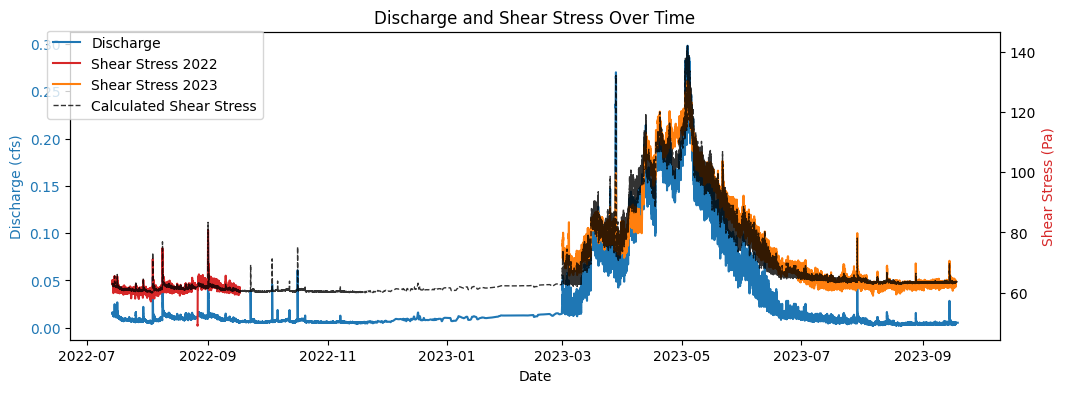

In [11]:
# plot discharge and shear stress over time
fig, ax1 = plt.subplots(figsize=(12, 4))
ax1.set_xlabel('Date')
ax1.set_ylabel('Discharge (cfs)', color='tab:blue') 
ax1.plot(discharge.index, discharge['discharge'], color='tab:blue', label='Discharge')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.set_ylabel('Shear Stress (Pa)', color='tab:red')
ax2.plot(discharge.index, discharge['0_x'], color='tab:red', label='Shear Stress 2022')
ax2.plot(discharge.index, discharge['0_y'], color='tab:orange', label='Shear Stress 2023')
ax2.plot(discharge.index, discharge['tau_calculated_linear'], color='black', label='Calculated Shear Stress', alpha=0.8, linestyle='--', linewidth=1)
ax2.tick_params(axis='y') 
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))
plt.title('Discharge and Shear Stress Over Time')
plt.show()

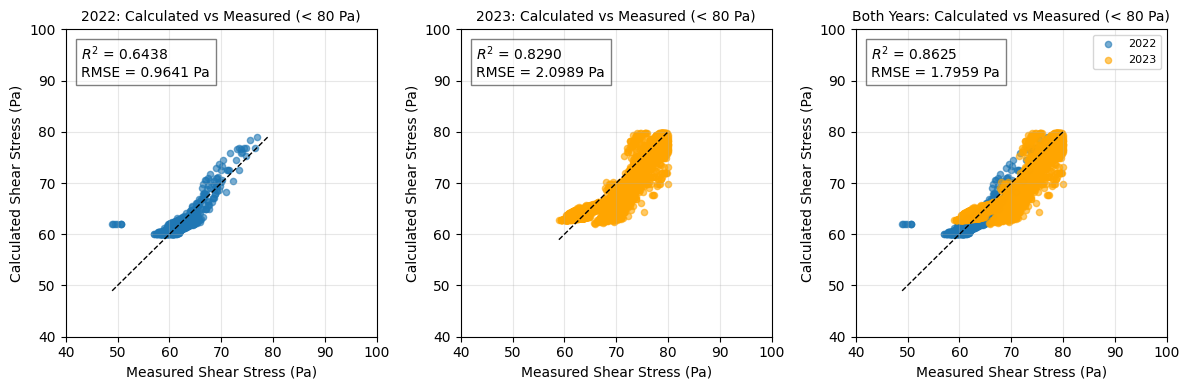

In [14]:
# Calculated vs measured shear stress (linear estimates)
low_stress_max = 80

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Build year-specific datasets
cmp_2022 = discharge.loc[discharge.index.year == 2022, ['0_x', 'tau_calculated_linear']].dropna()
cmp_2023 = discharge.loc[discharge.index.year == 2023, ['0_y', 'tau_calculated_linear']].dropna()

# Keep only low-stress points
cmp_2022 = cmp_2022[(cmp_2022['0_x'] <= low_stress_max) & (cmp_2022['tau_calculated_linear'] <= low_stress_max)]
cmp_2023 = cmp_2023[(cmp_2023['0_y'] <= low_stress_max) & (cmp_2023['tau_calculated_linear'] <= low_stress_max)]

cmp_both = pd.concat([
    cmp_2022.rename(columns={'0_x': 'measured'}),
    cmp_2023.rename(columns={'0_y': 'measured'})
])

# 2022
if len(cmp_2022) > 1:
    axes[0].scatter(cmp_2022['0_x'], cmp_2022['tau_calculated_linear'], alpha=0.6, s=20)
    min_2022 = min(cmp_2022['0_x'].min(), cmp_2022['tau_calculated_linear'].min())
    max_2022 = max(cmp_2022['0_x'].max(), cmp_2022['tau_calculated_linear'].max())
    axes[0].plot([min_2022, max_2022], [min_2022, max_2022], 'k--', linewidth=1)
    r2_2022_cmp = r2_score(cmp_2022['0_x'], cmp_2022['tau_calculated_linear'])
    rmse_2022_cmp = np.sqrt(np.mean((cmp_2022['0_x'] - cmp_2022['tau_calculated_linear'])**2))
    axes[0].text(0.05, 0.95, f'$R^2$ = {r2_2022_cmp:.4f}\nRMSE = {rmse_2022_cmp:.4f} Pa', transform=axes[0].transAxes,
                 verticalalignment='top', bbox=dict(facecolor='white', alpha=0.5))
else:
    axes[0].text(0.5, 0.5, 'No data after filter', ha='center', va='center', transform=axes[0].transAxes)
axes[0].set_title(f'2022: Calculated vs Measured (< {low_stress_max} Pa)', fontsize=10)
axes[0].set_xlabel('Measured Shear Stress (Pa)')
axes[0].set_ylabel('Calculated Shear Stress (Pa)')
axes[0].set_xlim(40, 100)
axes[0].set_ylim(40, 100)
axes[0].grid(True, alpha=0.3)

# 2023
if len(cmp_2023) > 1:
    axes[1].scatter(cmp_2023['0_y'], cmp_2023['tau_calculated_linear'], alpha=0.6, s=20, color='orange')
    min_2023 = min(cmp_2023['0_y'].min(), cmp_2023['tau_calculated_linear'].min())
    max_2023 = max(cmp_2023['0_y'].max(), cmp_2023['tau_calculated_linear'].max())
    axes[1].plot([min_2023, max_2023], [min_2023, max_2023], 'k--', linewidth=1)
    r2_2023_cmp = r2_score(cmp_2023['0_y'], cmp_2023['tau_calculated_linear'])
    rmse_2023_cmp = np.sqrt(np.mean((cmp_2023['0_y'] - cmp_2023['tau_calculated_linear'])**2))
    axes[1].text(0.05, 0.95, f'$R^2$ = {r2_2023_cmp:.4f}\nRMSE = {rmse_2023_cmp:.4f} Pa', transform=axes[1].transAxes,
                 verticalalignment='top', bbox=dict(facecolor='white', alpha=0.5))
else:
    axes[1].text(0.5, 0.5, 'No data after filter', ha='center', va='center', transform=axes[1].transAxes)
axes[1].set_title(f'2023: Calculated vs Measured (< {low_stress_max} Pa)', fontsize=10)
axes[1].set_xlabel('Measured Shear Stress (Pa)')
axes[1].set_ylabel('Calculated Shear Stress (Pa)')
axes[1].set_xlim(40, 100)
axes[1].set_ylim(40, 100)
axes[1].grid(True, alpha=0.3)

# Both years
if len(cmp_both) > 1:
    axes[2].scatter(cmp_2022['0_x'], cmp_2022['tau_calculated_linear'], alpha=0.6, s=20, label='2022')
    axes[2].scatter(cmp_2023['0_y'], cmp_2023['tau_calculated_linear'], alpha=0.6, s=20, color='orange', label='2023')
    min_both = min(cmp_both['measured'].min(), cmp_both['tau_calculated_linear'].min())
    max_both = max(cmp_both['measured'].max(), cmp_both['tau_calculated_linear'].max())
    axes[2].plot([min_both, max_both], [min_both, max_both], 'k--', linewidth=1)
    r2_both_cmp = r2_score(cmp_both['measured'], cmp_both['tau_calculated_linear'])
    rmse_both_cmp = np.sqrt(np.mean((cmp_both['measured'] - cmp_both['tau_calculated_linear'])**2))
    axes[2].text(0.05, 0.95, f'$R^2$ = {r2_both_cmp:.4f}\nRMSE = {rmse_both_cmp:.4f} Pa', transform=axes[2].transAxes,
                 verticalalignment='top', bbox=dict(facecolor='white', alpha=0.5))
    axes[2].legend(fontsize=8)
else:
    axes[2].text(0.5, 0.5, 'No data after filter', ha='center', va='center', transform=axes[2].transAxes)
axes[2].set_title(f'Both Years: Calculated vs Measured (< {low_stress_max} Pa)', fontsize=10)
axes[2].set_xlabel('Measured Shear Stress (Pa)')
axes[2].set_ylabel('Calculated Shear Stress (Pa)')
axes[2].set_xlim(40, 100)
axes[2].set_ylim(40, 100)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [38]:
# build one continuous shear stress dataframe:
# combine measured columns into a single measured series
tau_measured = discharge['0_x'].combine_first(discharge['0_y'])
tau_final = tau_measured.combine_first(discharge['tau_calculated_linear'])
# resample to 15 min intervals and fill data gaps 
tau_final = tau_final.resample('15min').interpolate()
# treat pre-September lows as missing, then re-interpolate
pre_sep_low = (tau_final.index < pd.Timestamp('2023-09-01')) & (tau_final < 55)
tau_final = tau_final.mask(pre_sep_low)
tau_final = tau_final.interpolate(method='time', limit_area='inside')
tau_final.columns = ['shear_stress']
print(tau_final.columns)

['shear_stress']


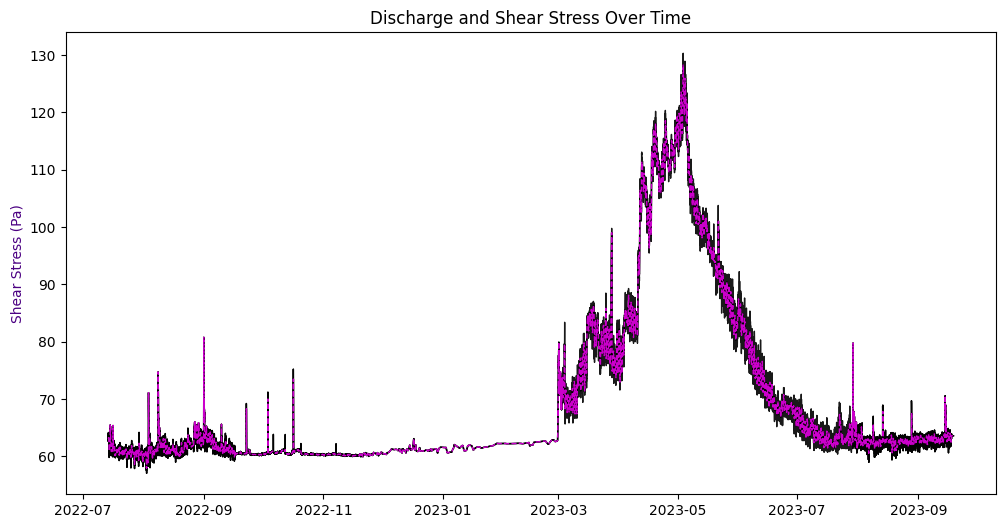

In [90]:
# copy original data
tau_final['shear_smooth'] = tau_final['shear_stress']
# select March–June period
mask = (tau_final.index >= pd.Timestamp('2023-03-03')) & (tau_final.index <= pd.Timestamp('2023-07-29'))
# apply smoothing only within this window
tau_final.loc[mask, 'shear_smooth'] = (
    tau_final.loc[mask, 'shear_stress']
    .rolling(window=20, center=True)
    .median()
)
threshold = 65   # Pa
# compute smoothing
baseflow_smooth = tau_final['shear_stress'].rolling(
    window=20, center=True
).median()
# apply smoothing only during baseflow
tau_final['shear_smooth_final'] = np.where(
    tau_final['shear_smooth'] < threshold,
    baseflow_smooth,
    tau_final['shear_smooth']
)
mask = (
    ((tau_final.index >= '2022-09-15') & (tau_final.index <= '2022-11-20')) |
    ((tau_final.index >= '2023-08-01') & (tau_final.index <= '2023-09-10'))
)
tau_final.loc[mask, 'shear_smooth_final'] = (
    tau_final.loc[mask, 'shear_smooth_final']
    .rolling(window=7, center=True)
    .median()
)

# plot discharge and shear stress over time
plt.figure(figsize=(12, 6))
plt.plot(tau_final.index, tau_final, color='black', label='Final Shear Stress', alpha=0.9, linestyle='-', linewidth=1)
plt.plot(tau_final.index, tau_final['shear_smooth_final'], color='magenta', label='Smoothed Shear Stress', alpha=0.8, linestyle='--', linewidth=1)
plt.tick_params(axis='y')   
plt.ylabel('Shear Stress (Pa)', color='indigo')
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))
plt.title('Discharge and Shear Stress Over Time')
plt.show()

In [91]:
# resample to 15 min intervals and fill data gaps 
tau_final = tau_final.resample('15min').interpolate()
# final dataframe 
shear_stress = pd.DataFrame({
    'datetime': tau_final.index,
    'shear_stress': tau_final['shear_smooth_final']
}).reset_index(drop=True)

# export to csv
shear_stress.to_csv('average_shear_stress_lajara_full.csv', index=False)

## Mobile Shear Stress

In [ ]:
# import shear stress data and make date the index
shear_stress_2022 = pd.read_csv('../mobile_shear_stress_2022.csv', index_col='time', parse_dates=True)
shear_stress_2023 = pd.read_csv('../mobile_shear_stress_2023.csv', index_col='time', parse_dates=True)

### Merge shear stress data onto discharge dataframe

In [13]:
# merge shear stress data onto discharge dataframe 
discharge = discharge.merge(shear_stress_2022, left_index=True, right_index=True, how='left')
discharge = discharge.merge(shear_stress_2023, left_index=True, right_index=True, how='left')

In [14]:
discharge

,discharge,tau_x,tau_y
timestamp,,,
2022-07-13 19:45:00,0.014394,2.806534,NaN
2022-07-13 20:00:00,0.013592,2.585446,NaN
2022-07-13 20:15:00,0.014394,2.850482,NaN
2022-07-13 20:30:00,0.014394,2.850482,NaN
2022-07-13 20:45:00,0.014394,2.809333,NaN
...,...,...,...
2023-09-17 22:45:00,0.005250,NaN,0.594255
2023-09-17 23:00:00,0.004656,NaN,0.503234
2023-09-17 23:15:00,0.004656,NaN,0.503234


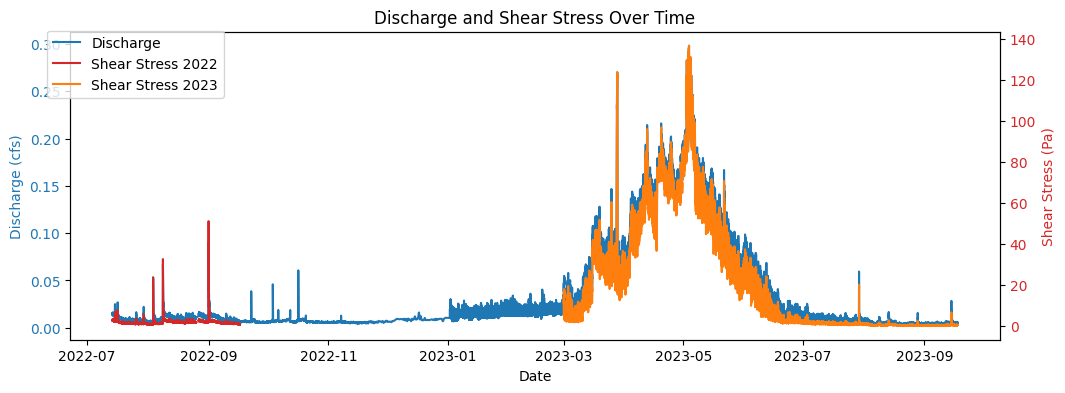

In [16]:
# plot discharge and shear stress over time
fig, ax1 = plt.subplots(figsize=(12, 4))
ax1.set_xlabel('Date')
ax1.set_ylabel('Discharge (cfs)', color='tab:blue') 
ax1.plot(discharge.index, discharge['discharge'], color='tab:blue', label='Discharge')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax2 = ax1.twinx()
ax2.set_ylabel('Shear Stress (Pa)', color='tab:red')
ax2.plot(discharge.index, discharge['tau_x'], color='tab:red', label='Shear Stress 2022')
ax2.plot(discharge.index, discharge['tau_y'], color='tab:orange', label='Shear Stress 2023')
ax2.tick_params(axis='y', labelcolor='tab:red') 
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))
plt.title('Discharge and Shear Stress Over Time')
plt.show()

Scatter plots

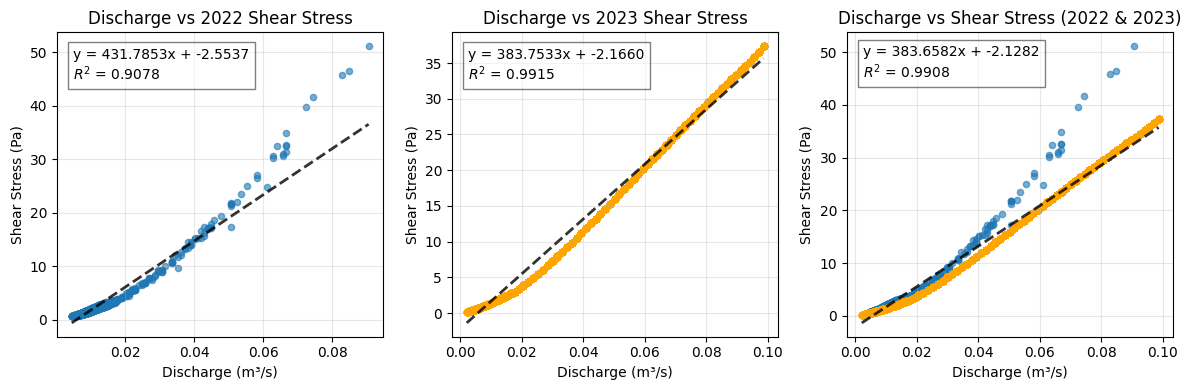

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# clean dataframes without NaN values and filter discharge <= 0.1
df_clean_2022 = discharge[['discharge', 'tau_x']].dropna()
df_clean_2022 = df_clean_2022[df_clean_2022['discharge'] <= 0.1]
df_clean_2023 = discharge[['discharge', 'tau_y']].dropna()
df_clean_2023 = df_clean_2023[df_clean_2023['discharge'] <= 0.1]

# discharge vs 2022 shear stress
axes[0].scatter(df_clean_2022['discharge'], df_clean_2022['tau_x'], alpha=0.6, s=20)
slope_2022, intercept_2022, r_value_2022, p_value_2022, std_err_2022 = linregress(df_clean_2022['discharge'], df_clean_2022['tau_x'])
x_line_2022 = np.array([df_clean_2022['discharge'].min(), df_clean_2022['discharge'].max()])
y_line_2022 = slope_2022 * x_line_2022 + intercept_2022
axes[0].plot(x_line_2022, y_line_2022, color='black', linestyle='--', alpha=0.8, linewidth=2)
axes[0].text(0.05, 0.95, f'y = {slope_2022:.4f}x + {intercept_2022:.4f}\n$R^2$ = {r_value_2022**2:.4f}', 
             transform=axes[0].transAxes, verticalalignment='top', bbox=dict(facecolor='white', alpha=0.5))
axes[0].set_xlabel('Discharge (m³/s)')
axes[0].set_ylabel('Shear Stress (Pa)')
axes[0].set_title('Discharge vs 2022 Shear Stress')
axes[0].grid(True, alpha=0.3)

# discharge vs 2023 shear stress
axes[1].scatter(df_clean_2023['discharge'], df_clean_2023['tau_y'], alpha=0.6, s=20, color='orange')
slope_2023, intercept_2023, r_value_2023, p_value_2023, std_err_2023 = linregress(df_clean_2023['discharge'], df_clean_2023['tau_y'])
x_line_2023 = np.array([df_clean_2023['discharge'].min(), df_clean_2023['discharge'].max()])
y_line_2023 = slope_2023 * x_line_2023 + intercept_2023
axes[1].plot(x_line_2023, y_line_2023, color='black', linestyle='--', alpha=0.8, linewidth=2)
axes[1].text(0.05, 0.95, f'y = {slope_2023:.4f}x + {intercept_2023:.4f}\n$R^2$ = {r_value_2023**2:.4f}', 
             transform=axes[1].transAxes, verticalalignment='top', bbox=dict(facecolor='white', alpha=0.5))
axes[1].set_xlabel('Discharge (m³/s)')
axes[1].set_ylabel('Shear Stress (Pa)')
axes[1].set_title('Discharge vs 2023 Shear Stress')
axes[1].grid(True, alpha=0.3)

# both years with single fit line
axes[2].scatter(df_clean_2022['discharge'], df_clean_2022['tau_x'], alpha=0.6, s=20, label='2022')
axes[2].scatter(df_clean_2023['discharge'], df_clean_2023['tau_y'], alpha=0.6, s=20, color='orange', label='2023')
# combine both datasets for single linear fit
combined_data = pd.concat([df_clean_2022[['discharge', 'tau_x']].rename(columns={'tau_x': 'shear_stress'}),
                           df_clean_2023[['discharge', 'tau_y']].rename(columns={'tau_y': 'shear_stress'})])
slope_combined, intercept_combined, r_value_combined, p_value_combined, std_err_combined = linregress(combined_data['discharge'], combined_data['shear_stress'])
x_line_combined = np.array([combined_data['discharge'].min(), combined_data['discharge'].max()])
y_line_combined = slope_combined * x_line_combined + intercept_combined
axes[2].plot(x_line_combined, y_line_combined, color='black', linestyle='--', alpha=0.8, linewidth=2, label=f'Combined fit: $R^2$ = {r_value_combined**2:.4f}')

axes[2].set_xlabel('Discharge (m³/s)')
axes[2].set_ylabel('Shear Stress (Pa)')
axes[2].set_title('Discharge vs Shear Stress (2022 & 2023)')
axes[2].text(0.05, 0.85, f'y = {slope_combined:.4f}x + {intercept_combined:.4f}\n$R^2$ = {r_value_combined**2:.4f}', 
             transform=axes[2].transAxes, bbox=dict(facecolor='white', alpha=0.5))
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

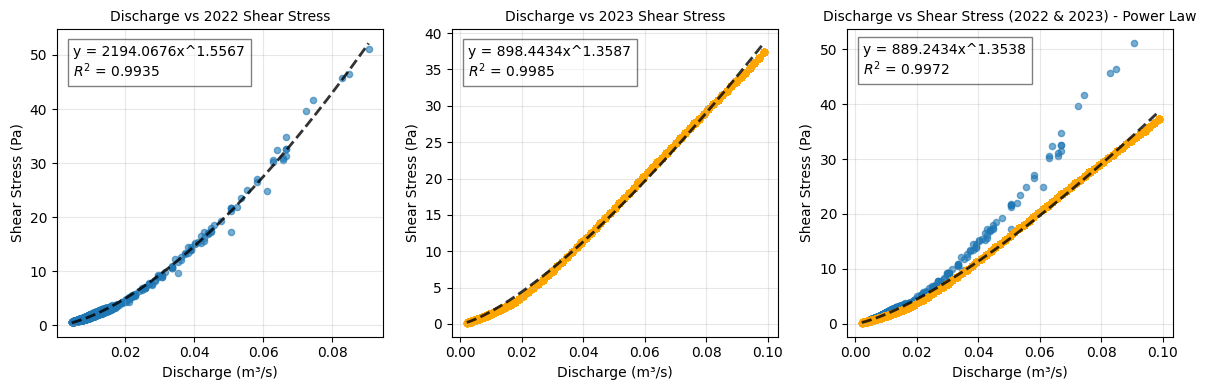

In [33]:
# define power law function
def power_law(x, a, b):
    return a * np.power(x, b)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# discharge vs 2022 shear stress
axes[0].scatter(df_clean_2022['discharge'], df_clean_2022['tau_x'], alpha=0.6, s=20)
try:
    popt_2022, pcov_2022 = curve_fit(power_law, df_clean_2022['discharge'], df_clean_2022['tau_x'], p0=[1, 2], maxfev=10000)
    x_line_2022_pw = np.linspace(df_clean_2022['discharge'].min(), df_clean_2022['discharge'].max(), 100)
    y_line_2022_pw = power_law(x_line_2022_pw, *popt_2022)
    y_pred_2022_pw = power_law(df_clean_2022['discharge'], *popt_2022)
    r2_2022_pw = r2_score(df_clean_2022['tau_x'], y_pred_2022_pw)
    axes[0].plot(x_line_2022_pw, y_line_2022_pw, color='black', alpha=0.8, linewidth=2, linestyle='--')
    axes[0].text(0.05, 0.95, f'y = {popt_2022[0]:.4f}x^{popt_2022[1]:.4f}\n$R^2$ = {r2_2022_pw:.4f}', 
                 transform=axes[0].transAxes, verticalalignment='top', bbox=dict(facecolor='white', alpha=0.5))
except:
    axes[0].text(0.5, 0.5, 'Fit failed', ha='center', va='center', transform=axes[0].transAxes)
axes[0].set_xlabel('Discharge (m³/s)')
axes[0].set_ylabel('Shear Stress (Pa)')
axes[0].set_title('Discharge vs 2022 Shear Stress', fontsize=10)
axes[0].grid(True, alpha=0.3)

# discharge vs 2023 shear stress
axes[1].scatter(df_clean_2023['discharge'], df_clean_2023['tau_y'], alpha=0.6, s=20, color='orange')
try:
    popt_2023, pcov_2023 = curve_fit(power_law, df_clean_2023['discharge'], df_clean_2023['tau_y'], p0=[1, 2], maxfev=10000)
    x_line_2023_pw = np.linspace(df_clean_2023['discharge'].min(), df_clean_2023['discharge'].max(), 100)
    y_line_2023_pw = power_law(x_line_2023_pw, *popt_2023)
    y_pred_2023_pw = power_law(df_clean_2023['discharge'], *popt_2023)
    r2_2023_pw = r2_score(df_clean_2023['tau_y'], y_pred_2023_pw)
    axes[1].plot(x_line_2023_pw, y_line_2023_pw, color='black', alpha=0.8, linewidth=2, linestyle='--')
    axes[1].text(0.05, 0.95, f'y = {popt_2023[0]:.4f}x^{popt_2023[1]:.4f}\n$R^2$ = {r2_2023_pw:.4f}', 
                 transform=axes[1].transAxes, verticalalignment='top', bbox=dict(facecolor='white', alpha=0.5))
except:
    axes[1].text(0.5, 0.5, 'Fit failed', ha='center', va='center', transform=axes[1].transAxes)
axes[1].set_xlabel('Discharge (m³/s)')
axes[1].set_ylabel('Shear Stress (Pa)')
axes[1].set_title('Discharge vs 2023 Shear Stress', fontsize=10)
axes[1].grid(True, alpha=0.3)

# both years with power law fit
axes[2].scatter(df_clean_2022['discharge'], df_clean_2022['tau_x'], alpha=0.6, s=20, label='2022')
axes[2].scatter(df_clean_2023['discharge'], df_clean_2023['tau_y'], alpha=0.6, s=20, color='orange', label='2023')
try:
    popt_combined, pcov_combined = curve_fit(power_law, combined_data['discharge'], combined_data['shear_stress'], p0=[1, 2], maxfev=10000)
    x_line_combined_pw = np.linspace(combined_data['discharge'].min(), combined_data['discharge'].max(), 100)
    y_line_combined_pw = power_law(x_line_combined_pw, *popt_combined)
    y_pred_combined_pw = power_law(combined_data['discharge'], *popt_combined)
    r2_combined_pw = r2_score(combined_data['shear_stress'], y_pred_combined_pw)
    axes[2].plot(x_line_combined_pw, y_line_combined_pw, color='black', linestyle='--', alpha=0.8, linewidth=2, label=f'Combined fit: $R^2$ = {r2_combined_pw:.4f}')
    axes[2].text(0.05, 0.85, f'y = {popt_combined[0]:.4f}x^{popt_combined[1]:.4f}\n$R^2$ = {r2_combined_pw:.4f}', 
                 transform=axes[2].transAxes, bbox=dict(facecolor='white', alpha=0.5))
except:
    axes[2].text(0.5, 0.5, 'Fit failed', ha='center', va='center', transform=axes[2].transAxes)
axes[2].set_xlabel('Discharge (m³/s)')
axes[2].set_ylabel('Shear Stress (Pa)')
axes[2].set_title('Discharge vs Shear Stress (2022 & 2023) - Power Law', fontsize=10)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Calculate shear stress using equations

In [42]:
# calculate shear stress using year-specific power-law fits
# 2022 uses popt_2022, 2023 uses popt_2023: tau = a * Q^b

discharge['tau_calculated'] = np.nan

q = discharge['discharge']
years = discharge.index.year

# power-law is only valid for positive discharge; keep fit range <= 0.1 used above
valid_q = q.notna() & (q > 0)
mask_2022 = (years == 2022) & valid_q
mask_2023 = (years == 2023) & valid_q

discharge.loc[mask_2022, 'tau_calculated'] = power_law(q.loc[mask_2022], *popt_2022)
discharge.loc[mask_2023, 'tau_calculated'] = power_law(q.loc[mask_2023], *popt_2023)

# quick check
print(discharge[['discharge', 'tau_calculated']])

                     discharge  tau_calculated
timestamp                                     
2022-07-13 19:45:00   0.014394        2.979627
2022-07-13 20:00:00   0.013592        2.725179
2022-07-13 20:15:00   0.014394        2.979627
2022-07-13 20:30:00   0.014394        2.979627
2022-07-13 20:45:00   0.014394        2.979627
...                        ...             ...
2023-09-17 22:45:00   0.005250        0.717507
2023-09-17 23:00:00   0.004656        0.609615
2023-09-17 23:15:00   0.004656        0.609615
2023-09-17 23:30:00   0.005901        0.841177
2023-09-17 23:45:00   0.005250        0.717507

[39340 rows x 2 columns]


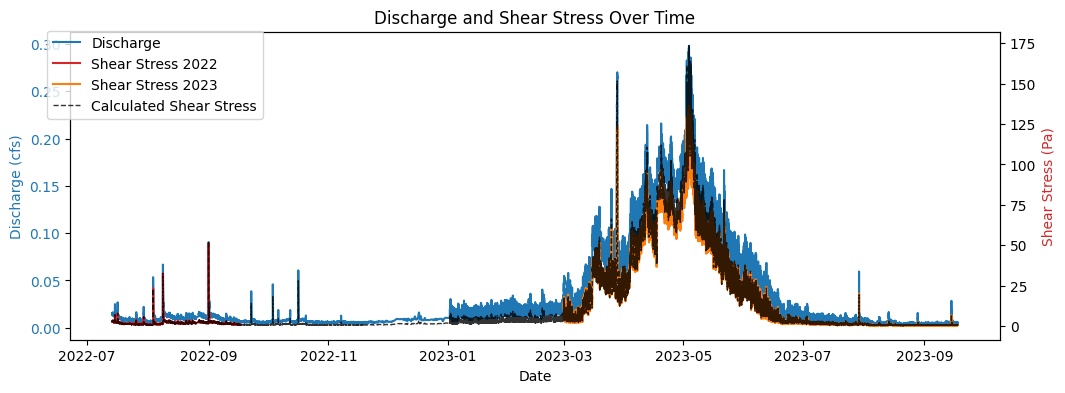

In [46]:
# plot discharge and shear stress over time
fig, ax1 = plt.subplots(figsize=(12, 4))
ax1.set_xlabel('Date')
ax1.set_ylabel('Discharge (cfs)', color='tab:blue') 
ax1.plot(discharge.index, discharge['discharge'], color='tab:blue', label='Discharge')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.set_ylabel('Shear Stress (Pa)', color='tab:red')
ax2.plot(discharge.index, discharge['tau_x'], color='tab:red', label='Shear Stress 2022')
ax2.plot(discharge.index, discharge['tau_y'], color='tab:orange', label='Shear Stress 2023')
ax2.plot(discharge.index, discharge['tau_calculated'], color='black', label='Calculated Shear Stress', alpha=0.8, linestyle='--', linewidth=1)
ax2.tick_params(axis='y') 
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))
plt.title('Discharge and Shear Stress Over Time')
plt.show()

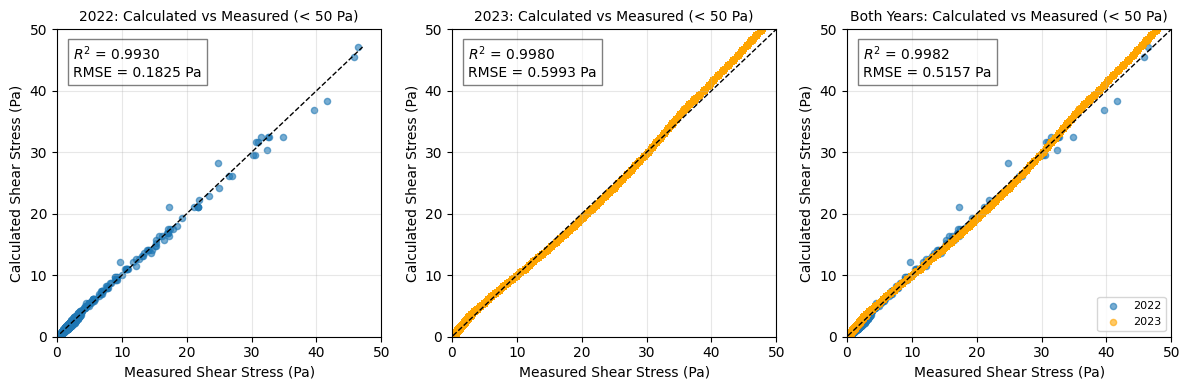

In [50]:
# Calculated vs measured shear stress (power-law estimates)
# Filter to low shear stress range (~50 Pa)
low_stress_max = 50

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Build year-specific datasets
cmp_2022 = discharge.loc[discharge.index.year == 2022, ['tau_x', 'tau_calculated']].dropna()
cmp_2023 = discharge.loc[discharge.index.year == 2023, ['tau_y', 'tau_calculated']].dropna()

# Keep only low-stress points
cmp_2022 = cmp_2022[(cmp_2022['tau_x'] <= low_stress_max) & (cmp_2022['tau_calculated'] <= low_stress_max)]
cmp_2023 = cmp_2023[(cmp_2023['tau_y'] <= low_stress_max) & (cmp_2023['tau_calculated'] <= low_stress_max)]

cmp_both = pd.concat([
    cmp_2022.rename(columns={'tau_x': 'measured'}),
    cmp_2023.rename(columns={'tau_y': 'measured'})
])

# 2022
axes[0].scatter(cmp_2022['tau_x'], cmp_2022['tau_calculated'], alpha=0.6, s=20)
min_2022 = min(cmp_2022['tau_x'].min(), cmp_2022['tau_calculated'].min())
max_2022 = max(cmp_2022['tau_x'].max(), cmp_2022['tau_calculated'].max())
axes[0].plot([min_2022, max_2022], [min_2022, max_2022], 'k--', linewidth=1)
r2_2022_cmp = r2_score(cmp_2022['tau_x'], cmp_2022['tau_calculated'])
rmse_2022_cmp = np.sqrt(np.mean((cmp_2022['tau_x'] - cmp_2022['tau_calculated'])**2))
axes[0].text(0.05, 0.95, f'$R^2$ = {r2_2022_cmp:.4f}\nRMSE = {rmse_2022_cmp:.4f} Pa', transform=axes[0].transAxes,
             verticalalignment='top', bbox=dict(facecolor='white', alpha=0.5))
axes[0].set_title('2022: Calculated vs Measured (< 50 Pa)', fontsize=10)
axes[0].set_xlabel('Measured Shear Stress (Pa)')
axes[0].set_ylabel('Calculated Shear Stress (Pa)')
axes[0].set_xlim(0, low_stress_max)
axes[0].set_ylim(0, low_stress_max)
axes[0].grid(True, alpha=0.3)

# 2023
axes[1].scatter(cmp_2023['tau_y'], cmp_2023['tau_calculated'], alpha=0.6, s=20, color='orange')
min_2023 = min(cmp_2023['tau_y'].min(), cmp_2023['tau_calculated'].min())
max_2023 = max(cmp_2023['tau_y'].max(), cmp_2023['tau_calculated'].max())
axes[1].plot([min_2023, max_2023], [min_2023, max_2023], 'k--', linewidth=1)
rmse_2023_cmp = np.sqrt(np.mean((cmp_2023['tau_y'] - cmp_2023['tau_calculated'])**2))
axes[1].text(0.05, 0.95, f'$R^2$ = {r2_2023_cmp:.4f}\nRMSE = {rmse_2023_cmp:.4f} Pa', transform=axes[1].transAxes,
             verticalalignment='top', bbox=dict(facecolor='white', alpha=0.5))
axes[1].set_title('2023: Calculated vs Measured (< 50 Pa)', fontsize=10)
axes[1].set_xlabel('Measured Shear Stress (Pa)')
axes[1].set_ylabel('Calculated Shear Stress (Pa)')
axes[1].set_xlim(0, low_stress_max)
axes[1].set_ylim(0, low_stress_max)
axes[1].grid(True, alpha=0.3)

# Both years
axes[2].scatter(cmp_2022['tau_x'], cmp_2022['tau_calculated'], alpha=0.6, s=20, label='2022')
axes[2].scatter(cmp_2023['tau_y'], cmp_2023['tau_calculated'], alpha=0.6, s=20, color='orange', label='2023')
min_both = min(cmp_both['measured'].min(), cmp_both['tau_calculated'].min())
max_both = max(cmp_both['measured'].max(), cmp_both['tau_calculated'].max())
axes[2].plot([min_both, max_both], [min_both, max_both], 'k--', linewidth=1)
rmse_both_cmp = np.sqrt(np.mean((cmp_both['measured'] - cmp_both['tau_calculated'])**2))
axes[2].text(0.05, 0.95, f'$R^2$ = {r2_both_cmp:.4f}\nRMSE = {rmse_both_cmp:.4f} Pa', transform=axes[2].transAxes,
             verticalalignment='top', bbox=dict(facecolor='white', alpha=0.5))
axes[2].set_title('Both Years: Calculated vs Measured (< 50 Pa)', fontsize=10)
axes[2].set_xlabel('Measured Shear Stress (Pa)')
axes[2].set_ylabel('Calculated Shear Stress (Pa)')
axes[2].set_xlim(0, low_stress_max)
axes[2].set_ylim(0, low_stress_max)
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()

plt.show()


Combine dataframes to keep calculated shear stresses in data gap

In [48]:
# build one continuous shear stress dataframe:
# combine measured columns into a single measured series
tau_measured = discharge['tau_x'].combine_first(discharge['tau_y'])
# fill measured gaps with calculated shear stress
tau_final = tau_measured.combine_first(discharge['tau_calculated'])

# final dataframe 
shear_stress = pd.DataFrame({
    'datetime': discharge.index,
    'shear_stress': tau_final
}).reset_index(drop=True)

# export to csv
shear_stress.to_csv('shear_stress_lajara_full.csv', index=False)